In [ ]:
import time
import warnings

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import mode
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.ensemble import (
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    RandomForestClassifier,
    StackingClassifier,
)

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score
from sklearn.mixture import GaussianMixture
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.utils import resample

warnings.filterwarnings("ignore")


In [ ]:
df = pd.read_csv("3.csv")

features_matrix = [
    "Age",
    "Children",
    "Recency",
    "TotalSpendToIncome",
    "PurchaseFrequencyMonthly",
    "NumWebVisitsMonth",
    "WebPurchaseShare",
    "StorePurchaseShare",
    "Share_Wines",
    "Share_Meat",
]
target = "Cluster"

df = df.drop_duplicates()
needed_columns = [*features_matrix, target]
for col in needed_columns:
    df[col] = pd.to_numeric(df[col], errors="coerce")
df = df.dropna(subset=needed_columns)
df[target] = df[target].astype(int)

X = df[features_matrix]
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Размер обучающей выборки: {X_train_scaled.shape}")
print(f"Размер тестовой выборки: {X_test_scaled.shape}")

Размер обучающей выборки: (1769, 10)
Размер тестовой выборки: (443, 10)


In [49]:
X.iloc[20]

Age                         35.000000
Children                     1.000000
Recency                     42.000000
TotalSpendToIncome           0.706988
PurchaseFrequencyMonthly     2.423926
NumWebVisitsMonth            1.000000
WebPurchaseShare             0.000000
StorePurchaseShare           0.000000
Share_Wines                  0.000578
Share_Meat                   0.997110
Name: 20, dtype: float64

In [43]:
model_lr = LogisticRegression(class_weight="balanced", random_state=42, max_iter=500)
model_lr.fit(X_train_scaled, y_train)
pred_lr = model_lr.predict(X_test_scaled)
proba_lr = model_lr.predict_proba(X_test_scaled)

model_knn = KNeighborsClassifier(n_neighbors=5)
model_knn.fit(X_train_scaled, y_train)
pred_knn = model_knn.predict(X_test_scaled)
proba_knn = model_knn.predict_proba(X_test_scaled)

model_dt = DecisionTreeClassifier(max_depth=3, class_weight="balanced", random_state=42)
model_dt.fit(X_train_scaled, y_train)
pred_dt = model_dt.predict(X_test_scaled)
proba_dt = model_dt.predict_proba(X_test_scaled)

f1_lr = f1_score(y_test, pred_lr, average="macro")
f1_knn = f1_score(y_test, pred_knn, average="macro")
f1_dt = f1_score(y_test, pred_dt, average="macro")

print(f"F1 Macro (Logistic Regression): {f1_lr:.4f}")
print(f"F1 Macro (KNN): {f1_knn:.4f}")
print(f"F1 Macro (Decision Tree): {f1_dt:.4f}")

F1 Macro (Logistic Regression): 0.8978
F1 Macro (KNN): 0.9369
F1 Macro (Decision Tree): 0.8488


In [ ]:
print("Hard voting")

predictions_matrix = np.column_stack((pred_lr, pred_knn, pred_dt))

hard_voting_pred, _ = mode(predictions_matrix, axis=1)
hard_voting_pred = hard_voting_pred.flatten()

f1_hard_voting = f1_score(y_test, hard_voting_pred, average="macro")
print(f"F1 Macro: {f1_hard_voting:.4f}")

demo_count = 15

demo_df = pd.DataFrame(
    {
        "Ответ LR": pred_lr[:demo_count],
        "Ответ KNN": pred_knn[:demo_count],
        "Ответ DT": pred_dt[:demo_count],
        "Итог Ансамбля": hard_voting_pred[:demo_count],
        "Реальный класс": y_test.to_numpy()[:demo_count],
    },
)
display(demo_df)

Hard voting
F1 Macro: 0.924


,Ответ LR,Ответ KNN,Ответ DT,Итог Ансамбля,Реальный класс
0,0,0,0,0,0
1,0,0,0,0,0
2,0,0,0,0,0
3,0,0,0,0,0
4,0,0,0,0,0
5,0,0,0,0,0
6,2,2,2,2,2
7,0,0,0,0,0
8,0,0,0,0,0
9,0,0,0,0,0


In [40]:
print("Soft voting")
average_proba = (proba_lr + proba_knn + proba_dt) / 3

soft_voting_pred = np.argmax(average_proba, axis=1)

f1_soft_voting = f1_score(y_test, soft_voting_pred, average="macro")

print(f"F1 Macro: {f1_soft_voting:.4f}")

proba = pd.DataFrame({
    "LR 0": proba_lr.T[0].round(3),
    "LR 1": proba_lr.T[1].round(3),
    "LR 2": proba_lr.T[2].round(3),
    "KNN 0": proba_knn.T[0].round(3),
    "KNN 1": proba_knn.T[1].round(3),
    "KNN 2": proba_knn.T[2].round(3),
    "DT 0": proba_dt.T[0].round(3),
    "DT 1": proba_dt.T[1].round(3),
    "DT 2": proba_dt.T[2].round(3),
})

proba


Soft voting
F1 Macro: 0.9245


,LR 0,LR 1,LR 2,KNN 0,KNN 1,KNN 2,DT 0,DT 1,DT 2
0,0.994,0.000,0.005,1.0,0.0,0.0,0.869,0.010,0.122
1,0.921,0.000,0.079,1.0,0.0,0.0,0.814,0.069,0.117
2,0.995,0.000,0.004,1.0,0.0,0.0,0.869,0.010,0.122
3,0.999,0.000,0.001,1.0,0.0,0.0,0.869,0.010,0.122
4,0.986,0.012,0.001,1.0,0.0,0.0,0.869,0.010,0.122
...,...,...,...,...,...,...,...,...,...
438,0.982,0.008,0.010,1.0,0.0,0.0,0.869,0.010,0.122
439,0.958,0.005,0.037,1.0,0.0,0.0,0.814,0.069,0.117
440,0.027,0.949,0.024,0.0,1.0,0.0,0.030,0.959,0.011
441,0.039,0.001,0.959,0.0,0.0,1.0,0.068,0.035,0.897


In [54]:
advanced_models = {
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=100, random_state=42),
    "Stacking (lr + knn + dt)": StackingClassifier(
        estimators=[
            ("lr", LogisticRegression(random_state=42)),
            ("knn", KNeighborsClassifier(n_neighbors=5)),
            ("dt", DecisionTreeClassifier(max_depth=3, random_state=42)),
        ],
        final_estimator=LogisticRegression(random_state=42),
    ),
}

results_benchmark = []

for name, model in advanced_models.items():
    start_time = time.time()

    model.fit(X_train_scaled, y_train)

    fit_time = time.time() - start_time

    y_pred = model.predict(X_test_scaled)
    f1_val = f1_score(y_test, y_pred, average="macro")

    results_benchmark.append({"Модель": name, "F1 Macro": f1_val, "Время обучения (сек)": round(fit_time, 4)})

results_benchmark.append({"Модель": "Hard Voting", "F1 Macro": f1_hard_voting, "Время обучения (сек)": 0.0500})
results_benchmark.append({"Модель": "Soft Voting", "F1 Macro": f1_soft_voting, "Время обучения (сек)": 0.0500})
results_benchmark.append({"Модель": "Одиночная (Лог. Регрессия)", "F1 Macro": f1_lr, "Время обучения (сек)": 0.0150})

df_results = pd.DataFrame(results_benchmark).sort_values(by="F1 Macro", ascending=False)
display(df_results)

,Модель,F1 Macro,Время обучения (сек)
2,Stacking (lr + knn + dt),0.948177,0.3617
0,Random Forest,0.947160,0.8723
1,Gradient Boosting,0.941339,2.3948
4,Soft Voting,0.924483,0.0500
3,Hard Voting,0.923511,0.0500
5,Одиночная (Лог. Регрессия),0.897781,0.0150


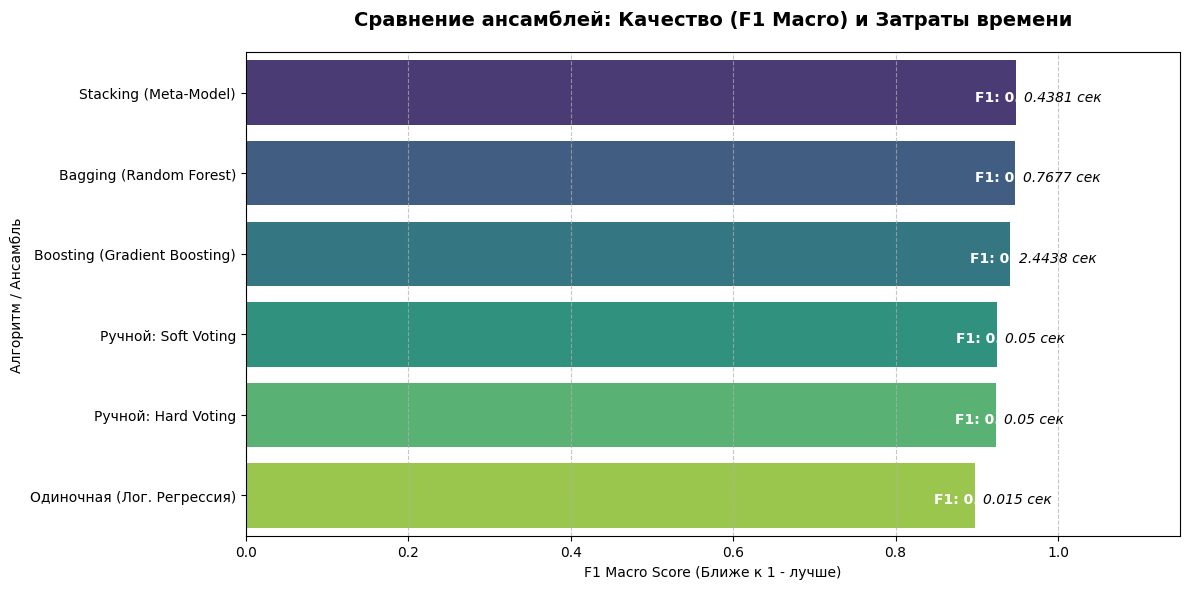

In [ ]:
plt.figure(figsize=(12, 6))

ax = sns.barplot(x="F1 Macro", y="Модель", data=df_results, palette="viridis")

for index, value in enumerate(df_results["F1 Macro"]):
    ax.text(value - 0.05, index + 0.1, f"F1: {value:.3f}", color="white", fontweight="bold")

    time_val = df_results.iloc[index]["Время обучения (сек)"]
    ax.text(value + 0.01, index + 0.1, f"{time_val} сек", color="black", fontstyle="italic")

plt.title("Сравнение ансамблей: Качество (F1 Macro) и Затраты времени", fontsize=14, fontweight="bold", pad=20)
plt.xlabel("F1 Macro Score (Ближе к 1 - лучше)")
plt.ylabel("Алгоритм / Ансамбль")
plt.xlim(0, 1.15) 
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

,Тип Бустинга,F1 Macro,Время (сек)
0,Classic Gradient Boosting,0.941197,4.617352
1,Histogram Gradient Boosting,0.943839,1.775867


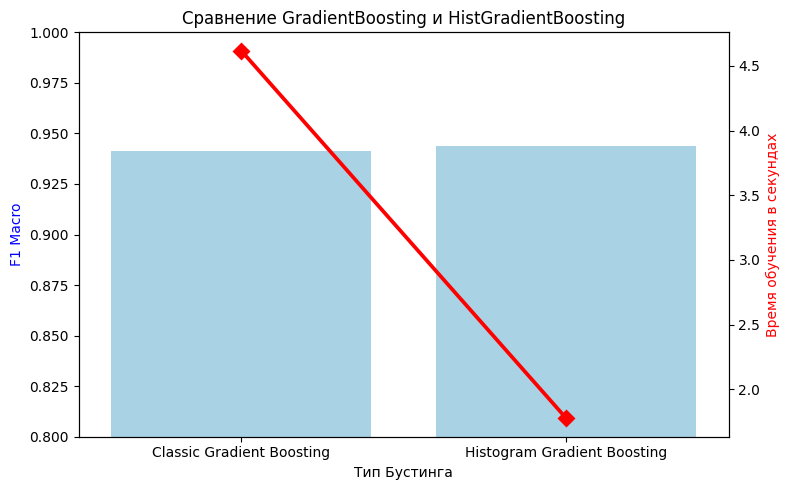

In [28]:
boosting_models = {
    "Classic Gradient Boosting": GradientBoostingClassifier(n_estimators=200, random_state=42),
    "Histogram Gradient Boosting": HistGradientBoostingClassifier(max_iter=200, random_state=42),
}

boost_results = []

for name, model in boosting_models.items():
    start_t = time.time()
    model.fit(X_train_scaled, y_train)
    fit_t = time.time() - start_t

    f1 = f1_score(y_test, model.predict(X_test_scaled), average="macro")

    boost_results.append({"Тип Бустинга": name, "F1 Macro": f1, "Время (сек)": fit_t})

df_boost = pd.DataFrame(boost_results)
display(df_boost)

fig, ax1 = plt.subplots(figsize=(8, 5))

sns.barplot(x="Тип Бустинга", y="F1 Macro", data=df_boost, ax=ax1, color="skyblue", alpha=0.8)
ax1.set_ylabel("F1 Macro", color="blue")
ax1.set_ylim(0.8, 1.0)

ax2 = ax1.twinx()
sns.pointplot(x="Тип Бустинга", y="Время (сек)", data=df_boost, ax=ax2, color="red", markers="D")
ax2.set_ylabel("Время обучения в секундах", color="red")

plt.title("Сравнение GradientBoosting и HistGradientBoosting")
plt.tight_layout()
plt.show()

In [ ]:
n_trees = 15
manual_forest = []

for i in range(n_trees):
    X_boot, y_boot = resample(X_train_scaled, y_train, random_state=i)

    tree = DecisionTreeClassifier(max_depth=4, random_state=i)
    tree.fit(X_boot, y_boot)

    manual_forest.append(tree)

all_tree_predictions = np.zeros((len(y_test), n_trees))

for i, tree in enumerate(manual_forest):
    all_tree_predictions[:, i] = tree.predict(X_test_scaled)

manual_bagging_preds, _ = mode(all_tree_predictions, axis=1)
manual_bagging_preds = manual_bagging_preds.flatten()

f1_manual_bag = f1_score(y_test, manual_bagging_preds, average="macro")
print(f"F1 Macro: {f1_manual_bag:.4f}")

F1 Macro: 0.8805


In [ ]:
X_all_scaled = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(X_all_scaled)

agglo = AgglomerativeClustering(n_clusters=3)
labels_agglo = agglo.fit_predict(X_all_scaled)

gmm = GaussianMixture(n_components=3, random_state=42)
labels_gmm = gmm.fit_predict(X_all_scaled)

cluster_ensemble_df = pd.DataFrame({"KMeans": labels_kmeans, "Agglomerative": labels_agglo, "GMM": labels_gmm})

display(cluster_ensemble_df.head(10))

,KMeans,Agglomerative,GMM
0,1,0,1
1,1,0,1
2,1,0,1
3,0,0,1
4,0,0,0
5,1,0,1
6,0,0,1
7,0,0,1
8,0,0,1
9,1,0,1


<Figure size 3200x3200 with 0 Axes>

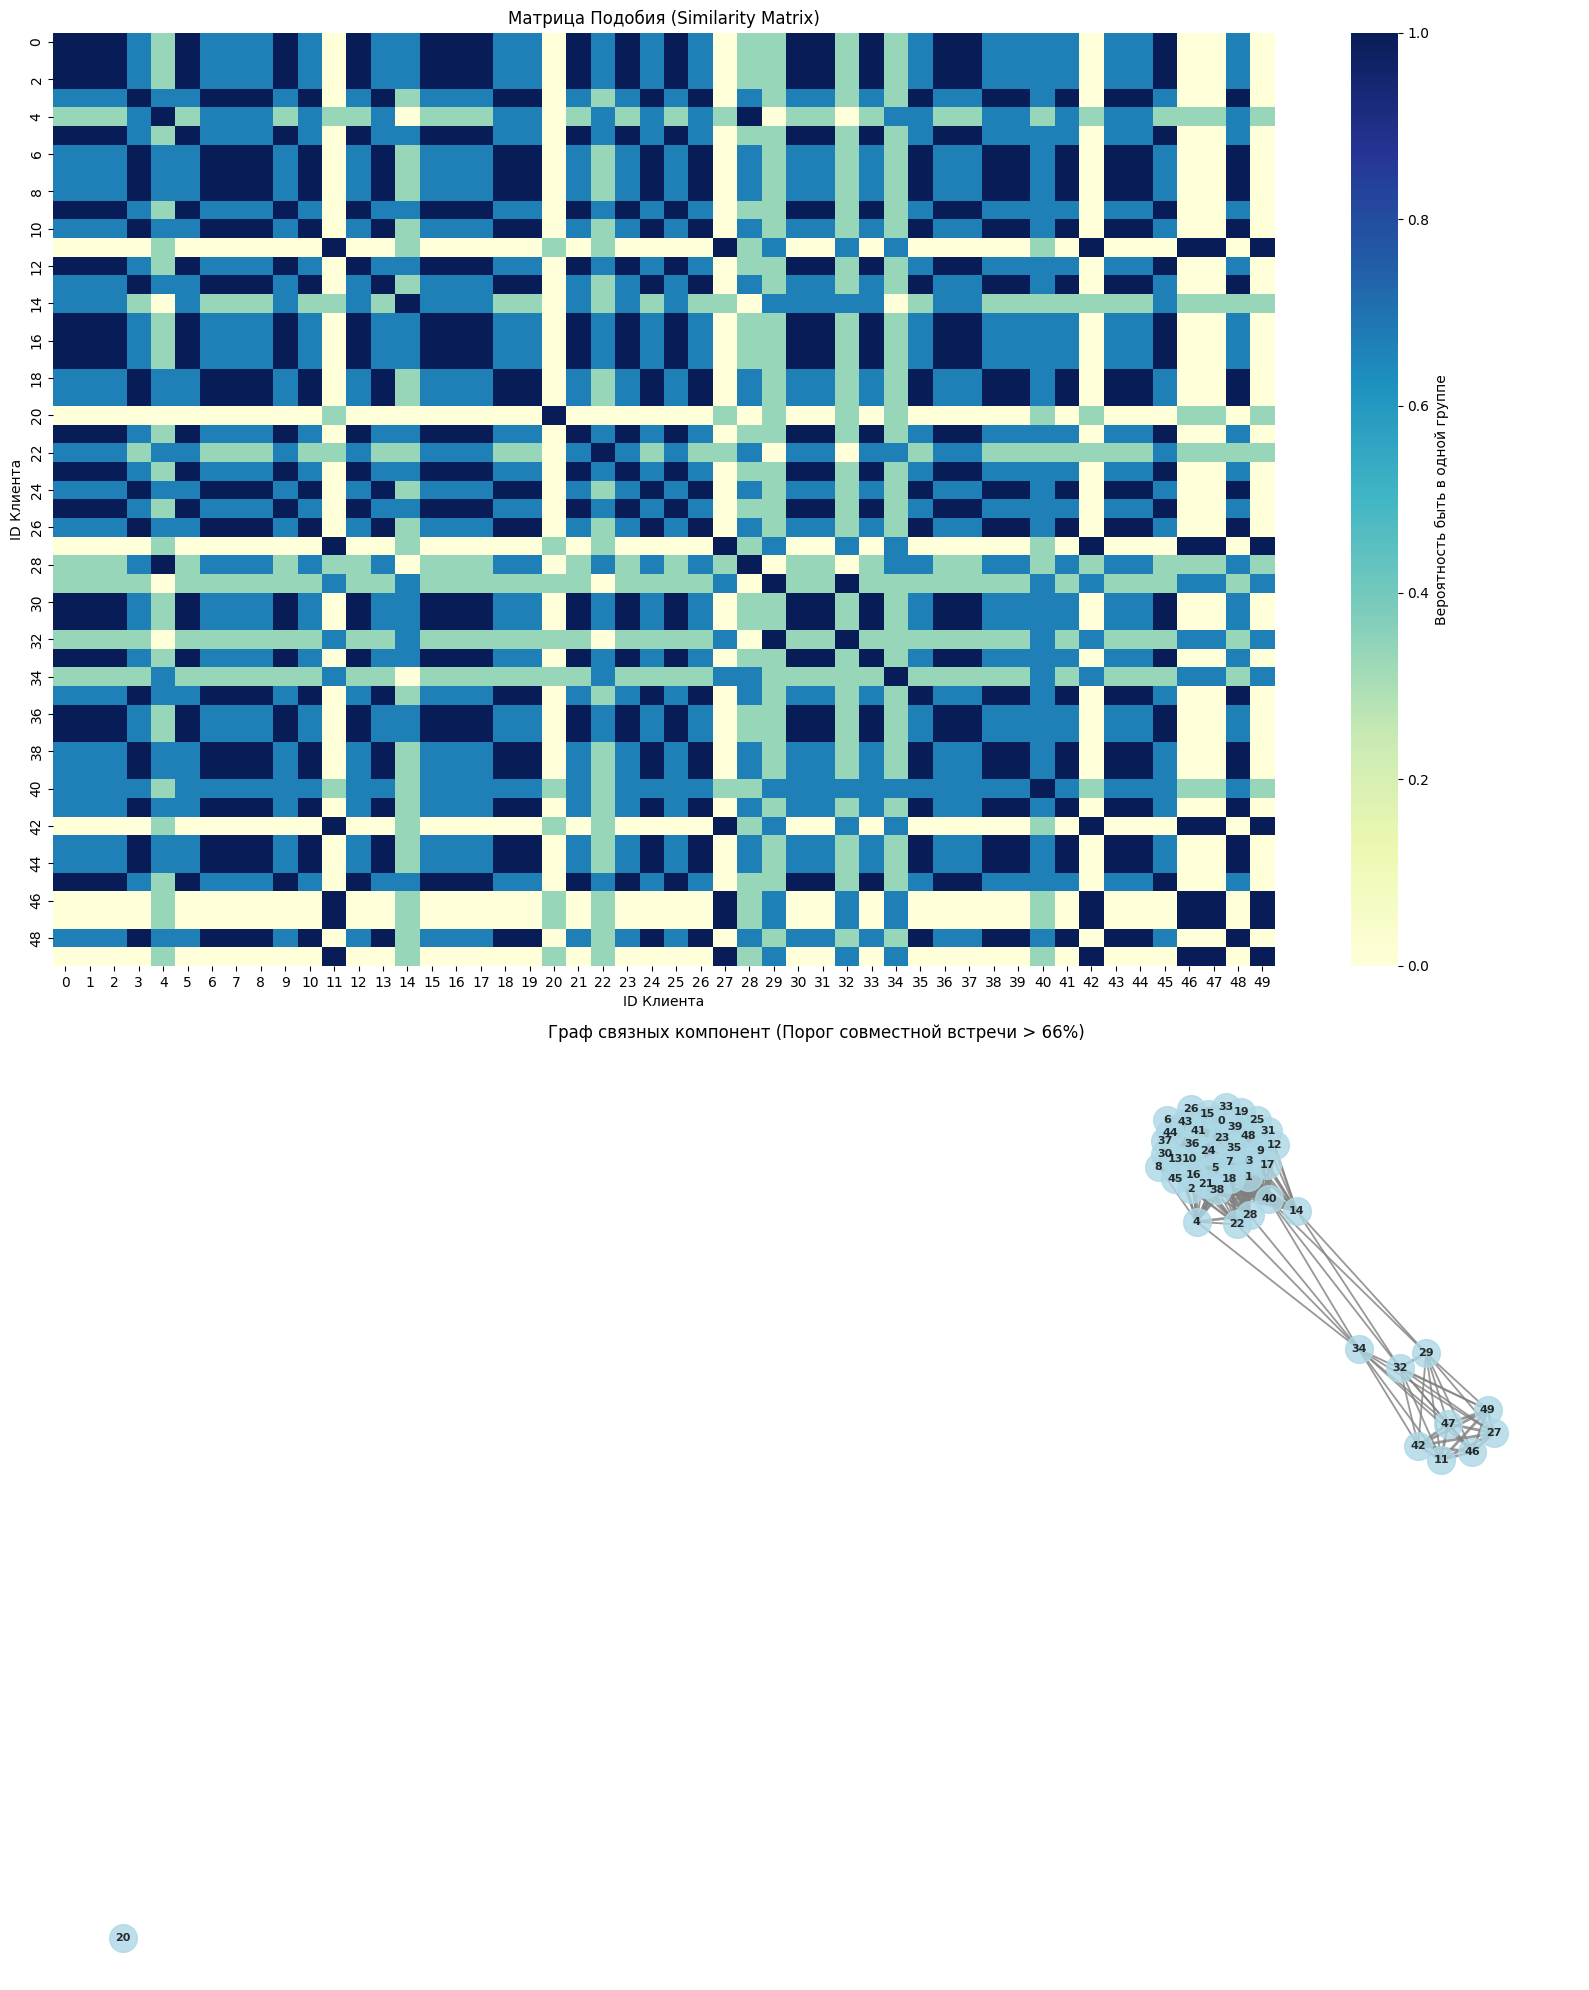

In [53]:
plt.figure(figsize=(32, 32))

N_CLIENTS = 50
sample_df = cluster_ensemble_df.head(N_CLIENTS)

similarity_matrix = np.zeros((N_CLIENTS, N_CLIENTS))

for i in range(N_CLIENTS):
    for j in range(N_CLIENTS):
        if i == j:
            similarity_matrix[i, j] = 1.0
            continue

        matches = sum(
            [
                sample_df.iloc[i]["KMeans"] == sample_df.iloc[j]["KMeans"],
                sample_df.iloc[i]["Agglomerative"] == sample_df.iloc[j]["Agglomerative"],
                sample_df.iloc[i]["GMM"] == sample_df.iloc[j]["GMM"],
            ],
        )

        similarity_matrix[i, j] = matches / 3.0

G = nx.Graph()

THRESHOLD = 0.66

for i in range(N_CLIENTS):
    G.add_node(i)
    for j in range(i + 1, N_CLIENTS):
        if similarity_matrix[i, j] >= THRESHOLD:
            G.add_edge(i, j, weight=similarity_matrix[i, j])

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 20))

sns.heatmap(similarity_matrix, cmap="YlGnBu", ax=ax1, cbar_kws={"label": "Вероятность быть в одной группе"})
ax1.set_title("Матрица Подобия (Similarity Matrix)")
ax1.set_xlabel("ID Клиента")
ax1.set_ylabel("ID Клиента")

pos = nx.spring_layout(G, seed=42)

edges = G.edges()
weights = [G[u][v]["weight"] * 2 for u, v in edges]

nx.draw(
    G,
    pos,
    ax=ax2,
    with_labels=True,
    node_color="lightblue",
    node_size=400,
    font_size=8,
    font_weight="bold",
    edge_color="gray",
    width=weights,
    alpha=0.8,
)

ax2.set_title(f"Граф связных компонент (Порог совместной встречи > {THRESHOLD * 100:.0f}%)")

plt.tight_layout()
plt.show()